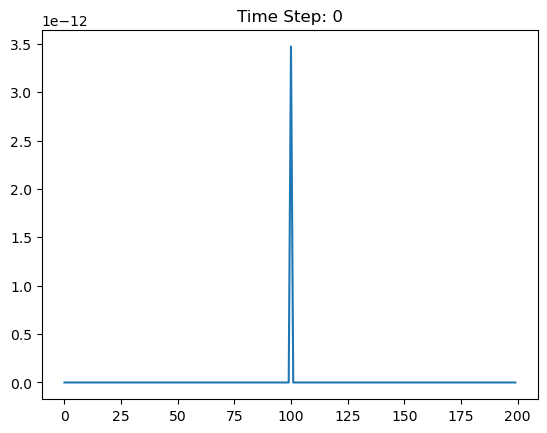

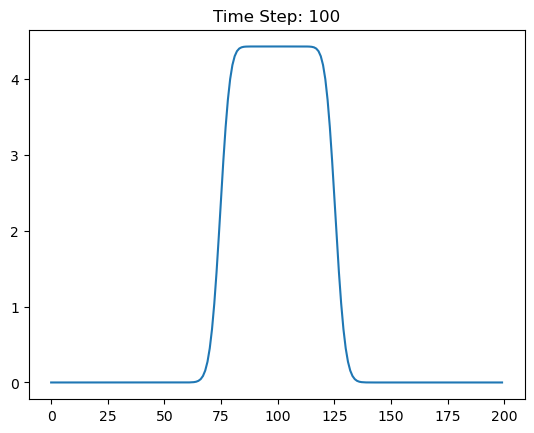

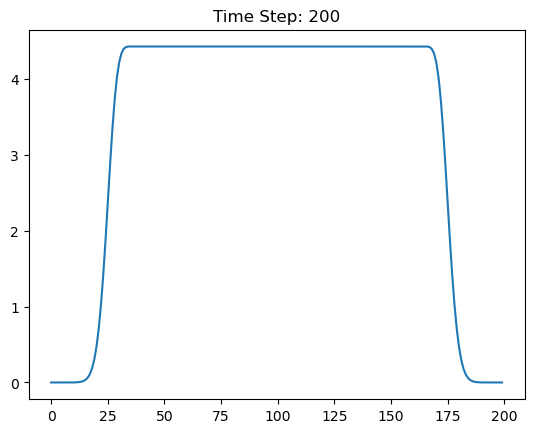

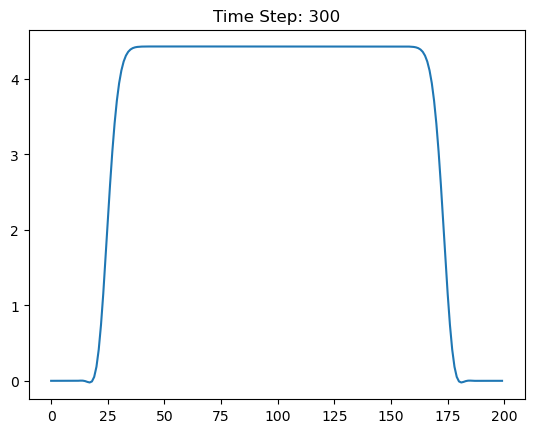

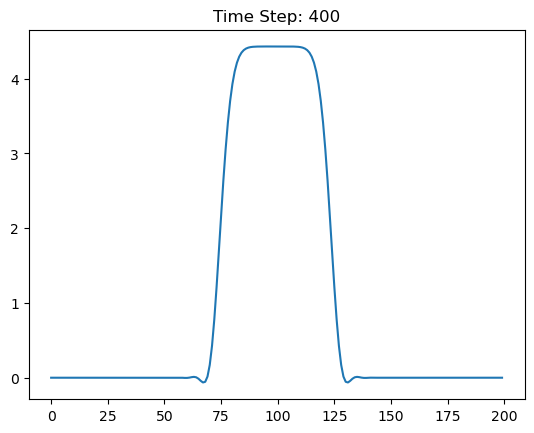

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 参数设置
nx = 200      # 空间网格数
nt = 500      # 时间步数
dx = 1.0      # 空间步长
c = 1.0       # 波速
dt = 0.5      # 时间步长 (需满足 CFL 条件)
isrc = 100    # 震源位置

# 2. 初始化数组
p = np.zeros(nx)
pold = np.zeros(nx)
d2p = np.zeros(nx)
pnew = np.zeros(nx)

# 3. 定义震源 (比如一个高斯脉冲)
src = np.exp(-0.01 * (np.arange(nt) - 50)**2)

# 4. 核心循环 (你图片中的代码)
for it in range(nt):
    # 计算二阶空间导数 (中心差分)
    for i in range(1, nx - 1):
        d2p[i] = (p[i + 1] - 2 * p[i] + p[i - 1]) / dx ** 2
    
    # 时间外推
    pnew = 2 * p - pold + dt ** 2 * c ** 2 * d2p
    
    # 添加震源
    pnew[isrc] = pnew[isrc] + dt ** 2 * src[it] / dx
    
    # 轮转时间层
    pold, p = p, pnew

    # 可选：每隔一段输出一下波形
    if it % 100 == 0:
        plt.plot(p)
        plt.title(f"Time Step: {it}")
        plt.show()

GIF 已生成！


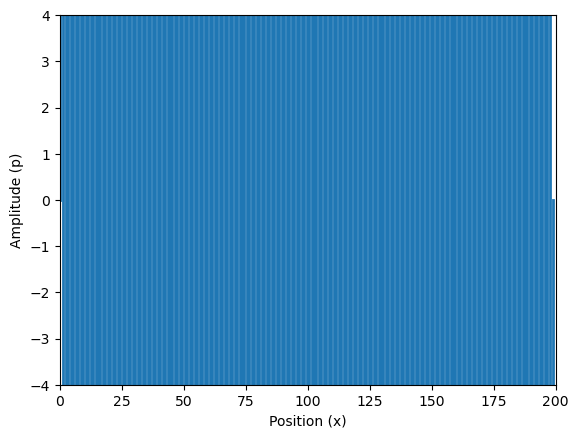

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# --- 1. 参数初始化 ---
nx = 200
nt = 300
dx = 0.4
c = 1.0
dt = 0.5
isrc = 100

p = np.zeros(nx)
pold = np.zeros(nx)
d2p = np.zeros(nx)
src = np.exp(-0.02 * (np.arange(nt) - 50)**2) # 震源脉冲

# --- 2. 绘图对象准备 ---
fig, ax = plt.subplots()
ax.set_xlim(0, nx)
ax.set_ylim(-4, 4) # 根据波动幅值调整
ax.set_xlabel('Position (x)')
ax.set_ylabel('Amplitude (p)')
line, = ax.plot([], [], lw=2)

# --- 3. 动画核心函数 ---
def init():
    line.set_data([], [])
    return line,

def update(it):
    global p, pold # 声明全局变量以在循环中更新
    
    # 你图片中的核心算法逻辑
    for i in range(1, nx - 1):
        d2p[i] = (p[i + 1] - 2 * p[i] + p[i - 1]) / dx ** 2
    
    pnew = 2 * p - pold + dt ** 2 * c ** 2 * d2p
    pnew[isrc] = pnew[isrc] + dt ** 2 * src[it] / dx
    
    # 时间层轮转
    pold[:] = p[:]
    p[:] = pnew[:]
    
    # 更新绘图数据
    line.set_data(np.arange(nx), p)
    return line,

# --- 4. 生成并保存动画 ---
# frames 是总帧数，interval 是每帧间隔毫秒
ani = FuncAnimation(fig, update, frames=range(nt), 
                    init_func=init, blit=True, interval=20)

# 保存为 GIF (确保安装了 pillow 库: pip install pillow)
ani.save('wave_simulation.gif', writer='pillow')

print("GIF 已生成！")